# Feature regressions — V-shapes (desk memo)

Causal Flora–Renò \(V_t\), \(T^\pm\) features × honest forward-return clocks. **Ridge primary**; OLS / ElasticNet / logistic secondary.

| | |
|--|--|
| Primary target | `y_tick_20` = next-20-trade log return (**trade-time clock**) |
| Primary result | **Hold** — \(R^2_\mathrm{te}<0\), IC CI includes 0, early/late unstable |
| Calendar | `y_cal_{30,60,300}s` — **Promote as Monitor only** (not sized) |
| Leakage \(V_\tau/T^+_\tau\) | **Kill** |
| Sample | n≈245k · ETH 20d · BTC 13d · HL+Deribit+Kraken |

**SoT:** [`NOTES.md`](NOTES.md) · [`EXP_REPORT.md`](EXP_REPORT.md) · [`CANDIDATES.md`](CANDIDATES.md) · artifacts [`../../out/feature_reg/`](../../out/feature_reg/) · Desk [`../../DESK_MEMO.md`](../../DESK_MEMO.md) §5b · Trade ideas [`../../notebooks/trade_ideas.ipynb`](../../notebooks/trade_ideas.ipynb) §8.

Script: [`../../scripts/exp_feature_reg.py`](../../scripts/exp_feature_reg.py). No soft-Promote. ClickHouse MCP banned.


## 1. Theory — what is being predicted

Flora & Renò continuous \(V_t\) is a local V-shape intensity on a price path. Decomposition:

- \(T^-_\tau\) — **left** kernel (causal at decision \(\tau\))
- \(T^+_\tau\) — **right** kernel (looks *after* \(\tau\) → leakage if used live)
- \(V_\tau = T^-_\tau + T^+_\tau\) — contemporaneous path statistic (same look-ahead risk)

**Desk claim under test:** do *causal* features (\(T^-\), lagged completed \(V\), running MinV, EGARCH breach, intensity/VPIN, geometric V-overlap) predict forward mid/tape returns under **named clocks**?

Clock choice matters: calendar conflates intensity; trade-time matches MM/SOR print decisions; volume-clock falsifies Cont-style time change.


## 2. Method — sampling honesty + models

| Item | Choice | Why |
|------|--------|-----|
| Price grid | **5s** last-print | Book legacy (`continuous_v` / widen) |
| Decision grid | every **30s** | Desk-speed; still dense for IC |
| Latency | features known at decision print | No exchange-RTT model |
| Look-ahead ban | no \(V_\tau\), \(T^+_\tau\) in primary X | Right kernel after \(\tau\) |
| Split | chronological ~60/40 by UTC day | No shuffle leak |
| Primary model | Ridge, \(\alpha\) via time-blocked CV | Collinear V-feats |
| Secondary | OLS, ElasticNet, logistic breach→sign(\(y\)) | Robustness / direction |
| Promote bar | \(R^2_\mathrm{te}>0\), IC CI excludes 0, \(\lvert\mathrm{IC}\rvert\ge0.05\), early∧late sign-stable | Desk discipline |

Causal X: `Tm`, `abs_Tm`, `Tm_1m`, `V_lag`, `abs_V_lag`, `running_min_v`, `abs_running_min_v`, `breach`, `geom_near`, `log_intensity`, `vpin_roll`, `hn5_dummy`.


## 3. Load artifacts + sample board


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/v_shapes')
OUT = BOOK / 'out' / 'feature_reg'
APP = BOOK / 'applications' / 'feature_reg'
FIG = OUT / 'figs'

summary = json.loads((OUT / 'summary.json').read_text())
gates = json.loads((OUT / 'gates.json').read_text())
coefs = json.loads((OUT / 'coef_tables.json').read_text())
meta = json.loads((OUT / 'panel_meta.json').read_text())
prim = json.loads((OUT / 'primary_fit.json').read_text())

samp = meta.get('sampling') or summary.get('sampling') or {}
print('primary_target', summary['primary_target'], '| clock', summary['primary_clock'])
print('n_rows', summary['n_rows'], '| ETH days', meta.get('n_days_eth'), '| BTC days', meta.get('n_days_btc'))
print('venues', meta.get('venues'))
print('causal feats', meta.get('causal_feats'))
print('leak feats (banned live)', meta.get('leak_feats'))
print()
print('sampling note:', (samp.get('note') or '')[:220])
print('latency:', samp.get('latency_assumption'))
print('look_ahead_ban:', samp.get('look_ahead_ban'))
print()
print('primary fit: n_train', prim.get('n_train'), 'n_test', prim.get('n_test'), 'α', round(float(prim.get('alpha') or 0), 4))
print('train_days', prim.get('train_days'))
print('test_days ', prim.get('test_days'))

# day coverage table
dm = pd.DataFrame(meta.get('day_meta') or [])
if len(dm):
    cov = (dm.groupby(['symbol', 'venue'], as_index=False)
             .agg(n_days=('day', 'nunique'), n_ok=('n_ok', 'sum')))
    display(cov)


primary_target y_tick_20 | clock trade_time_next_N_trades
n_rows 245928 | ETH days 20 | BTC days 13
venues ['hyperliquid', 'deribit', 'kraken']
causal feats ['Tm', 'abs_Tm', 'Tm_1m', 'V_lag', 'abs_V_lag', 'running_min_v', 'abs_running_min_v', 'breach', 'geom_near', 'log_intensity', 'vpin_roll', 'hn5_dummy']
leak feats (banned live) ['V_now', 'Tp']

sampling note: 5s last-print grid is book legacy (same as continuous_v / widen). Decision subsample every 30s. Tick/volume targets from raw tape. Causal features exclude contemporaneous V and T+ (right kernel).
latency: features known at decision print; no exchange-latency model
look_ahead_ban: V_now and Tp are leakage-only; never in primary design matrix

primary fit: n_train 159956 n_test 84982 α 0.6579
train_days ['2026-09-04', '2026-09-05', '2026-09-06', '2026-09-07', '2026-09-08', '2026-09-09', '2026-09-10', '2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18']
test_days  ['2026-09-19', '2026-09-20', '2026-09-21', '2026-

,symbol,venue,n_days,n_ok
0,BTC,deribit,13,33326
1,BTC,hyperliquid,13,34240
2,BTC,kraken,13,26542
3,ETH,deribit,20,53117
4,ETH,hyperliquid,20,54032
5,ETH,kraken,20,44671


## 4. Train / test split honesty

Chronological UTC-day cut (~60/40). Teal = train (earlier); red = test (later). No random shuffle — intensity regimes and stress days must land OOS honestly.


`figs/train_test_split.png`

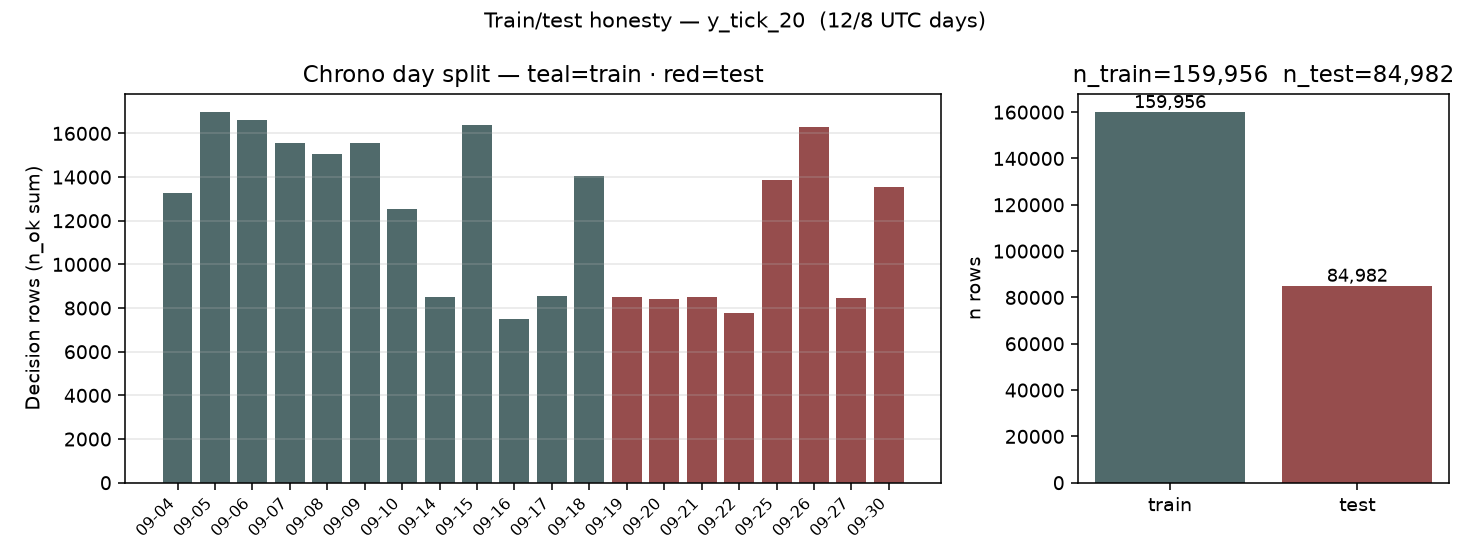

train/test days: 12 / 8
n_train/n_test: 159956 / 84982


In [2]:
for name in ['train_test_split.png']:
    p = FIG / name
    assert p.exists(), f'missing {p} — run: python scripts/exp_feature_reg.py --figs-only'
    display(Markdown(f'`figs/{name}`'))
    display(Image(filename=str(p)))
print('train/test days:', len(prim.get('train_days') or []), '/', len(prim.get('test_days') or []))
print('n_train/n_test:', prim.get('n_train'), '/', prim.get('n_test'))


## 5. Primary clock — `y_tick_20` (trade-time) → **Hold**

Trade-time next-N is the honest MM clock. OOS Ridge **fails** the Promote bar: negative \(R^2_\mathrm{te}\), IC bootstrap CI includes 0, early/late OOS IC unstable. `log_intensity` dwarfs V-features on the tick design matrix and does not travel OOS — **do not soft-Promote**.


In [3]:
blk = summary['results']['y_tick_20']
rg = blk['ridge']
ols_ic = blk.get('ols_ic')
en_ic = blk.get('en_ic')

rows = [{
    'model': 'Ridge',
    'R2_te': rg.get('r2_test'),
    'IC': rg.get('ic_test'),
    'IC_lo': (rg.get('ic_boot') or {}).get('lo'),
    'IC_hi': (rg.get('ic_boot') or {}).get('hi'),
    'excludes_0': (rg.get('ic_boot') or {}).get('excludes_0'),
    'IC_early': rg.get('ic_early_oos'),
    'IC_late': rg.get('ic_late_oos'),
    'sign_stable': rg.get('sign_stable'),
}]
# OLS / EN from primary_fit when present
for label, key in [('OLS', 'ols'), ('ElasticNet', 'elasticnet')]:
    m = prim.get(key) or {}
    if m:
        rows.append({
            'model': label,
            'R2_te': m.get('r2_test'),
            'IC': m.get('ic_test'),
            'IC_lo': None, 'IC_hi': None, 'excludes_0': None,
            'IC_early': None, 'IC_late': None, 'sign_stable': None,
        })
display(pd.DataFrame(rows))
print('decision_hint', blk.get('decision_hint'), '| promote_ok', blk.get('promote_ok'), '| α', blk.get('alpha'))
print('summary OLS IC', ols_ic, '| EN IC', en_ic)

coef = sorted((blk.get('coef') or (rg.get('coef') or {})).items(), key=lambda kv: -abs(kv[1]))
display(pd.DataFrame([{'feat': k, 'ridge_coef': v} for k, v in coef]))
print('→ intensity-dominated tick matrix + OOS collapse ⇒ Hold (IC monitor only)')


,model,R2_te,IC,IC_lo,IC_hi,excludes_0,IC_early,IC_late,sign_stable
0,Ridge,-1.247215,-0.087732,-0.191382,0.016086,0.0,-0.22006,0.004523,0.0
1,OLS,-1.247221,-0.087731,NaN,NaN,NaN,NaN,NaN,NaN
2,ElasticNet,-0.067541,-0.043261,NaN,NaN,NaN,NaN,NaN,NaN


decision_hint Hold | promote_ok 0 | α 0.6579332246575679
summary OLS IC -0.08773146131671015 | EN IC -0.043261420879691204


,feat,ridge_coef
0,log_intensity,0.001347
1,abs_running_min_v,0.000132
2,geom_near,-0.000108
3,breach,-0.000080
4,vpin_roll,0.000079
5,Tm,0.000049
6,abs_V_lag,-0.000048
7,abs_Tm,0.000022
8,Tm_1m,-0.000010
9,V_lag,-0.000006


→ intensity-dominated tick matrix + OOS collapse ⇒ Hold (IC monitor only)


## 6. All targets / clocks — Ridge + OLS/EN IC

Calendar 30s / 60s / 300s clear falsifiers (\(R^2_\mathrm{te}>0\), IC CI excludes 0, sign-stable) but effect sizes are **small** (\(R^2\) 0.3%–2.6%) → **Promote as info Monitor only**, never sized alpha. Volume-clock mirrors tick collapse.


In [4]:
rows = []
for key in ['y_tick_10', 'y_tick_20', 'y_tick_50', 'y_cal_30s', 'y_cal_60s', 'y_cal_300s', 'y_vol']:
    blk = summary['results'].get(key) or {}
    rg = blk.get('ridge') or {}
    boot = rg.get('ic_boot') or {}
    rows.append({
        'target': key,
        'n': blk.get('n'),
        'α': round(float(blk.get('alpha') or 0), 4) if blk.get('alpha') is not None else None,
        'R2_te': rg.get('r2_test'),
        'IC_ridge': rg.get('ic_test'),
        'IC_lo': boot.get('lo'),
        'IC_hi': boot.get('hi'),
        'excludes_0': boot.get('excludes_0'),
        'sign_stable': rg.get('sign_stable'),
        'OLS_IC': blk.get('ols_ic'),
        'EN_IC': blk.get('en_ic'),
        'promote_ok': blk.get('promote_ok'),
        'hint': blk.get('decision_hint'),
    })
display(pd.DataFrame(rows))

print()
print('Calendar 300s Ridge coefs (leading T− expected):')
c300 = ((coefs.get('y_cal_300s') or {}).get('ridge')) or (summary['results']['y_cal_300s'].get('coef') or {})
display(pd.DataFrame([
    {'feat': k, 'coef': v} for k, v in sorted(c300.items(), key=lambda kv: -abs(kv[1]))
]))


,target,n,α,R2_te,IC_ridge,IC_lo,IC_hi,excludes_0,sign_stable,OLS_IC,EN_IC,promote_ok,hint
0,y_tick_10,244938,0.0100,-1.262815,-0.094728,-0.197966,0.010300,0,0,-0.094728,-0.052184,0,Hold
1,y_tick_20,244938,0.6579,-1.247215,-0.087732,-0.191382,0.016086,0,0,-0.087731,-0.043261,0,Hold
2,y_tick_50,244934,0.6579,-1.234197,-0.075432,-0.179156,0.029488,0,0,-0.075433,-0.040052,0,Hold
3,y_cal_30s,244938,15.1991,0.003302,0.067571,0.059270,0.074996,1,1,0.067570,-0.003741,1,Promote
4,y_cal_60s,244938,5.3367,0.006299,0.096248,0.087443,0.107788,1,1,0.096248,-0.005388,1,Promote
5,y_cal_300s,244938,0.0285,0.025823,0.187391,0.170597,0.201415,1,1,0.187390,-0.008060,1,Promote
6,y_vol,244937,0.0811,-1.289737,-0.094820,-0.202199,0.007857,0,0,-0.094820,-0.048518,0,Hold



Calendar 300s Ridge coefs (leading T− expected):


,feat,coef
0,Tm,0.000306
1,abs_running_min_v,-0.000106
2,running_min_v,-0.000105
3,abs_V_lag,0.000090
4,Tm_1m,-0.000067
5,geom_near,-0.000063
6,V_lag,0.000059
7,log_intensity,0.000026
8,abs_Tm,-0.000021
9,vpin_roll,-0.000015


## 7. Key figures

IC by horizon · Ridge \(\alpha\) path · OOS scatter (primary) · tick coefs · calendar coefs · train/test honesty.


ic_by_horizon.png                exists=True bytes=39542


### `ic_by_horizon.png`

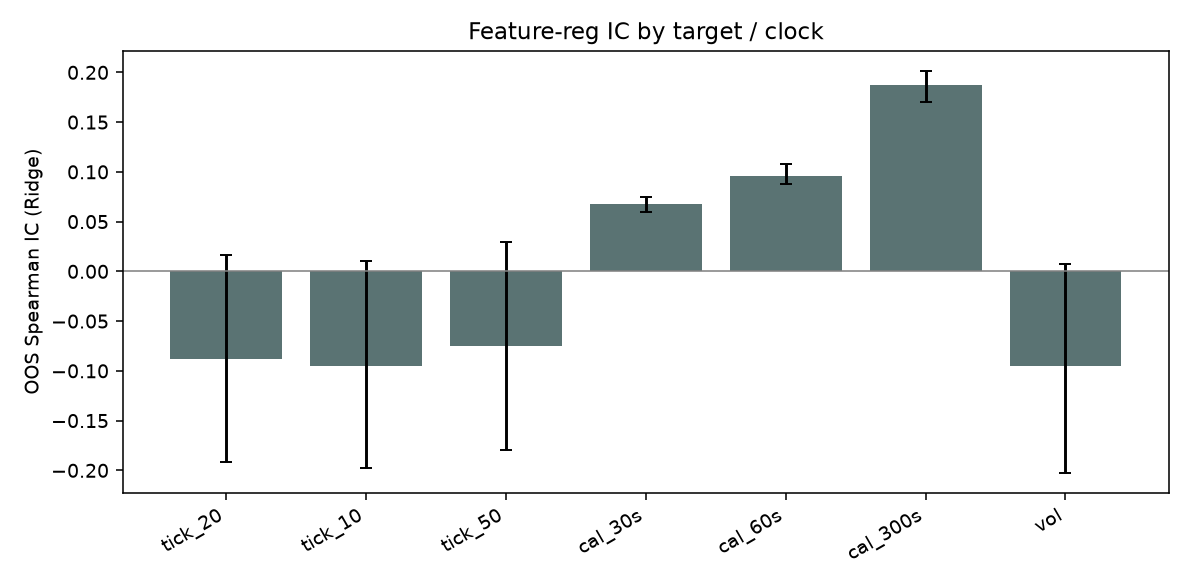

ridge_path.png                   exists=True bytes=48905


### `ridge_path.png`

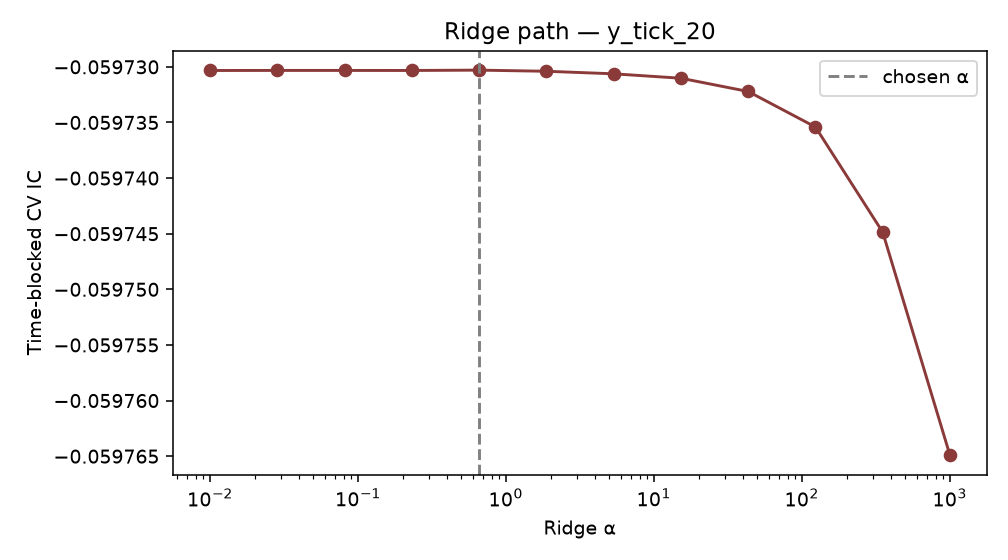

oos_scatter_primary.png          exists=True bytes=46881


### `oos_scatter_primary.png`

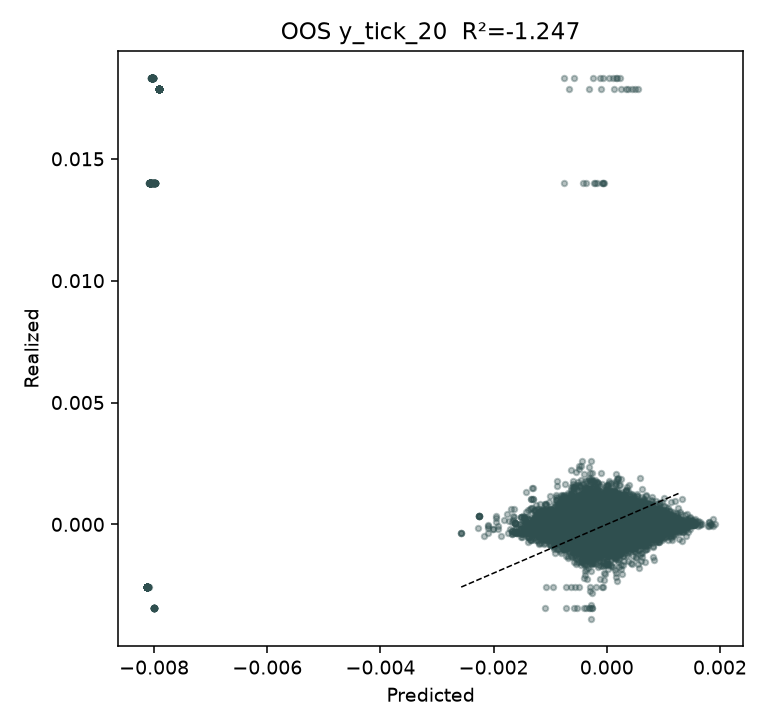

ridge_coefs_primary.png          exists=True bytes=39841


### `ridge_coefs_primary.png`

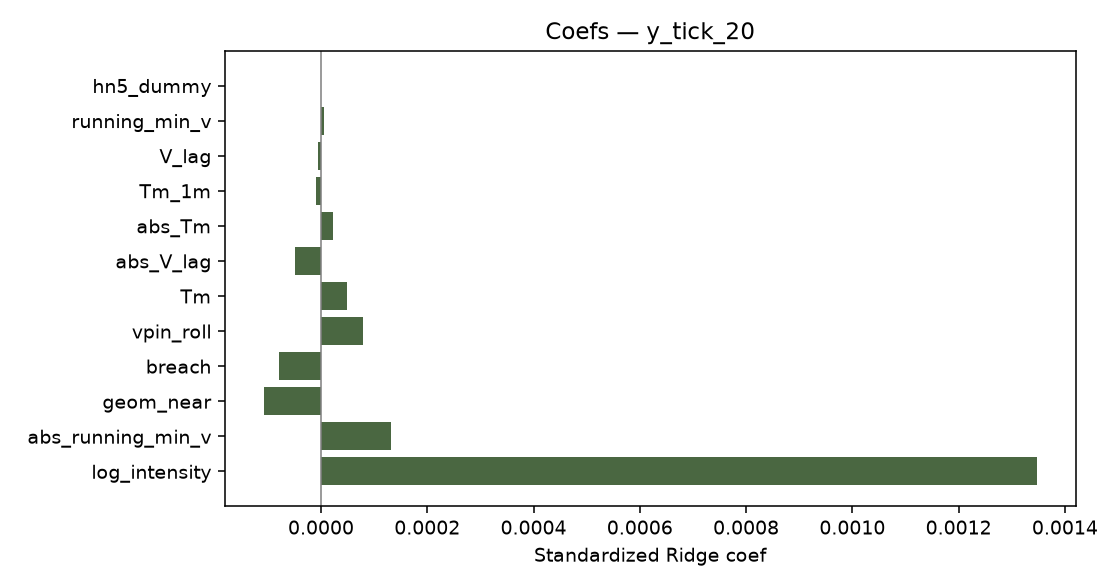

ridge_coefs_calendar.png         exists=True bytes=41142


### `ridge_coefs_calendar.png`

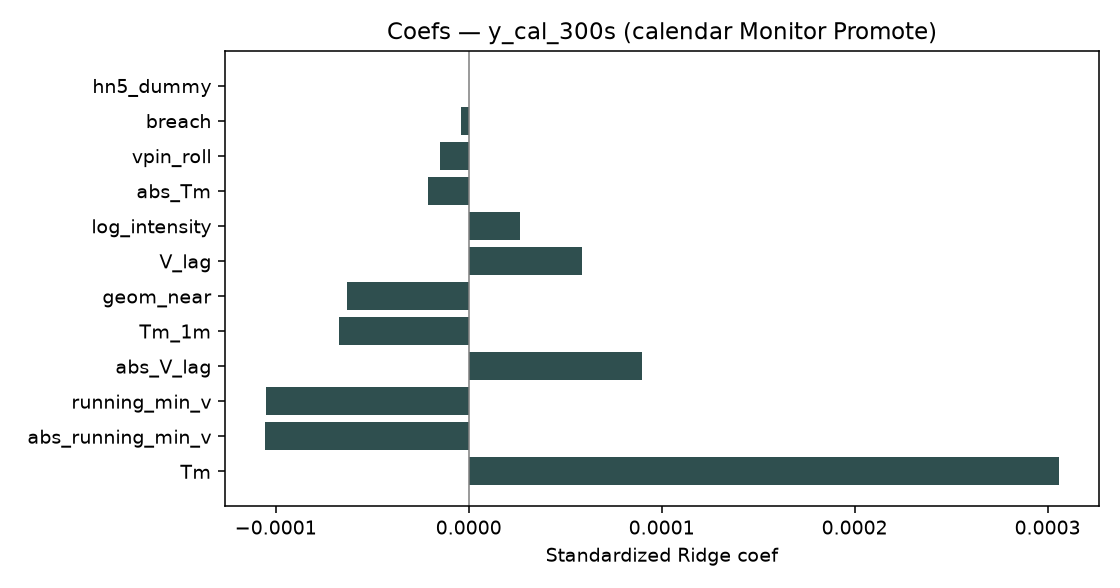

train_test_split.png             exists=True bytes=73564


### `train_test_split.png`

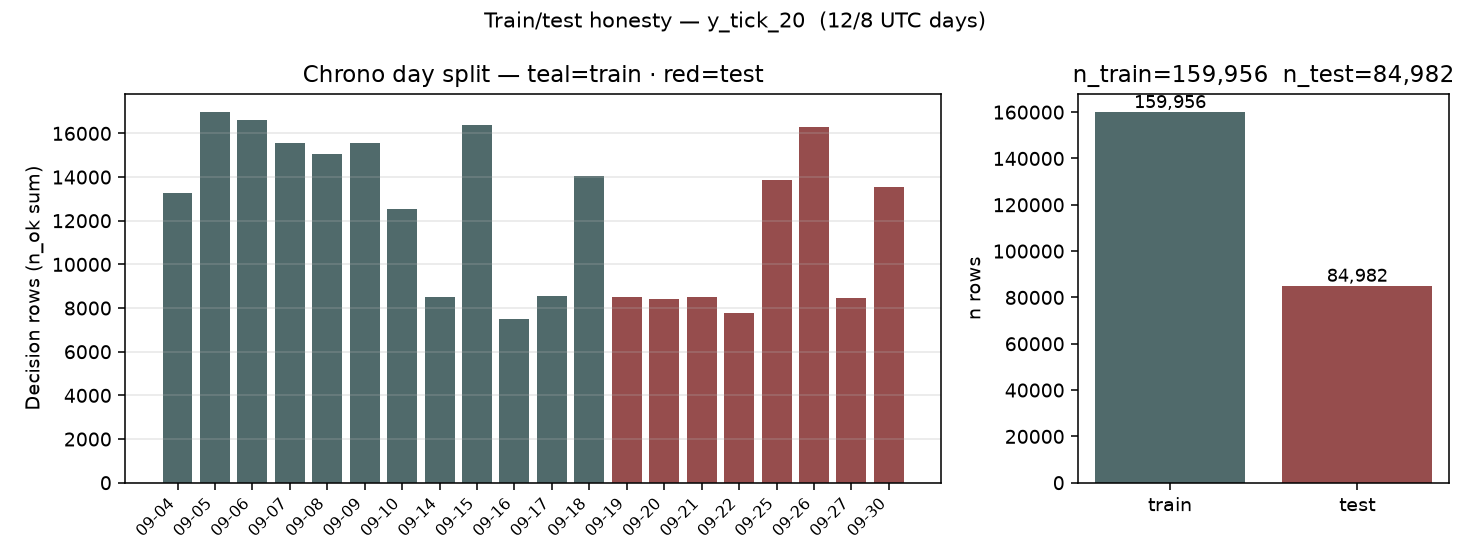

All key figures present and displayed.


In [5]:
FIG_NAMES = [
    'ic_by_horizon.png',
    'ridge_path.png',
    'oos_scatter_primary.png',
    'ridge_coefs_primary.png',
    'ridge_coefs_calendar.png',
    'train_test_split.png',
]
missing = []
for name in FIG_NAMES:
    p = FIG / name
    ok = p.exists() and p.stat().st_size > 1000
    print(f'{name:32s} exists={ok} bytes={p.stat().st_size if p.exists() else 0}')
    if not ok:
        missing.append(name)
        continue
    display(Markdown(f'### `{name}`'))
    display(Image(filename=str(p)))
assert not missing, f'missing/thin figs: {missing} — run exp_feature_reg.py --figs-only'
print('All key figures present and displayed.')


## 8. Falsifiers

1. **Leakage** — add contemporaneous \(V_\tau\) + \(T^+_\tau\). Does not rescue tick OOS → right-kernel features **Kill** as live inputs.
2. **Volume clock** — same OOS collapse as tick → Cont-clock does not salvage.
3. **Logistic breach→sign(\(y\))** — AUC≈ coin-flip → **Hold**.
4. **Calendar vs tick disagreement** — calendar Monitor Promote vs tick Hold is *expected* under intensity conflation; do not re-label tick as Promote.


In [6]:
leak = summary.get('leakage_check') or {}
caus = summary['results']['y_tick_20']['ridge']
print('=== leakage V_now+Tp vs causal (primary tick) ===')
print('causal  IC', caus.get('ic_test'), 'R2_te', caus.get('r2_test'))
print('leakage IC', leak.get('ic_test'), 'R2_te', leak.get('r2_test'), 'boot', leak.get('ic_boot'))
print('→ Kill live V_now/Tp; diagnostic only')

print()
vol = summary['results'].get('y_vol') or {}
print('=== volume clock ===')
print('R2_te', (vol.get('ridge') or {}).get('r2_test'), 'IC', (vol.get('ridge') or {}).get('ic_test'), 'hint', vol.get('decision_hint'))

print()
logi = summary.get('logistic_breach_sign') or {}
print('=== logistic breach → sign(y) ===')
print('AUC_te', logi.get('auc_test'), 'base', logi.get('base_rate') or logi.get('base'), 'hint', logi.get('decision_hint'))
lc = (coefs.get('logistic_breach_sign') or {})
if lc:
    display(pd.DataFrame([{'k': k, 'v': v} for k, v in lc.items() if not isinstance(v, dict)]))


=== leakage V_now+Tp vs causal (primary tick) ===
causal  IC -0.08773154190945692 R2_te -1.2472148427472054
leakage IC None R2_te None boot None
→ Kill live V_now/Tp; diagnostic only

=== volume clock ===
R2_te -1.2897365293752845 IC -0.09482005639221283 hint Hold

=== logistic breach → sign(y) ===
AUC_te 0.49077615465167557 base None hint Hold


,k,v
0,Tm,0.144976
1,abs_Tm,0.003051
2,Tm_1m,0.032499
3,V_lag,-0.002218
4,abs_V_lag,0.005266
5,running_min_v,-0.045089
6,abs_running_min_v,-0.030355
7,breach,-0.005430
8,geom_near,-0.013003
9,log_intensity,0.386763


## 9. Gate board — Promote / Hold / Kill

| Candidate | Decision | Desk use |
|-----------|----------|----------|
| `info.v_feature_ridge_tick` | **Hold** | Primary trade clock failed — IC monitor only |
| `info.v_feature_ridge_calendar` | **Promote** | Info / risk **Monitor** — not sized alpha |
| `info.v_feature_ridge_volume_clock` | **Hold** | Same collapse as tick |
| `info.v_feature_leakage_V_Tp` | **Kill** | Right-kernel features banned live |
| `info.breach_sign_logistic` | **Hold** | AUC≈0.49 coin-flip |

Current book Promotes (EGARCH / daily MinV / taxonomy / stress) **stay**. Prior Holds **stay Hold**. New ideas: Monitor / paper Exec throttle only.


In [7]:
print('=== CANDIDATES (from gates.json) ===')
for c in gates['candidates']:
    print(f"  {c['decision']:7s}  {c['id']:40s}  tradable={c.get('tradable')}")
    print(f"           {c['evidence'][:180]}")

print()
print('=== new trade ideas folded from feature_reg ===')
for idea in gates.get('trade_ideas_new') or []:
    print(f"  {idea['id']:32s}  {idea['label']:14s}  size={idea.get('tradable_size')}")
    print(f"    title: {idea.get('title')}")
    print(f"    gates: {idea.get('gate_status')}")
    print(f"    falsifier: {str(idea.get('falsifier'))[:160]}")
    print()

# cross-check CANDIDATES.md exists
cand_md = (APP / 'CANDIDATES.md').read_text()
print('CANDIDATES.md lines', len(cand_md.splitlines()))
print()
print('Done. Primary tick Hold; calendar Monitor Promote; leakage Kill. No soft-Promote.')


=== CANDIDATES (from gates.json) ===
  Hold     info.v_feature_ridge_tick                 tradable=0
           target=y_tick_20 clock=trade_time_next_N_trades; R²_te=-1.2472148427472054 IC=-0.08773154190945692 boot={'lo': -0.1913818998107668, 'hi': 0.01608586849978722, 'excludes_0': False} 
  Promote  info.v_feature_ridge_calendar             tradable=0
           y_cal_30s: R²=0.0033024445810511116 IC=0.06757144916075941 ok=True; y_cal_60s: R²=0.006298684914202601 IC=0.09624789054019979 ok=True; y_cal_300s: R²=0.02582315092272891 IC=0.18739
  Hold     info.v_feature_ridge_volume_clock         tradable=0
           R²_te=-1.2897365293752845 IC=-0.09482005639221283 n=244937
  Kill     info.v_feature_leakage_V_Tp               tradable=0
           leakage design (V_now+Tp+causal) IC=-0.08299407164024794 vs causal IC=-0.08773154190945692; right-kernel T+/contemporaneous V banned at decision time — Kill as live features
  Hold     info.breach_sign_logistic                 tradable=0
    

## 10. Desk mapping + next experiments

| Idea | Label | Gate |
|------|-------|------|
| `ti.v_feature_cal_monitor` | **Monitor** | calendar **Promote** |
| `ti.v_feature_ridge_monitor` | Monitor (Hold) | tick **Hold** |
| `ti.v_feature_throttle_join` | paper Exec throttle | calendar Promote + `info.v_path_continuous` Hold |

**Next (do not soft-Promote meanwhile):** ablate `log_intensity` on tick; venue FE; shorter N; require IC CI excludes 0 before any tick-clock Promote.

Pointers: [`../../DESK_MEMO.md`](../../DESK_MEMO.md) §5b · [`../../notebooks/trade_ideas.ipynb`](../../notebooks/trade_ideas.ipynb) §8 · [`../../notebooks/desk_synthesis.ipynb`](../../notebooks/desk_synthesis.ipynb).
